## **Image Classification Model - T5 Residual CNN**

### **Purpose**

The purpose of this notebook is to train and evaluate a residual CNN model for the Lexical Bridge Photo Mission feature. The model classifies uploaded images into one of nine target object classes, such as cat, dog, bird, flower, fruit, vegetable, car, bicycle, and shoe. This supports the game flow where a child is asked to take or upload a photo of a specific object, and the system checks whether the image matches the requested class.

This notebook improves the previous CNN architecture by replacing the simple convolutional feature extractor with a residual CNN structure. After the initial stem convolution layer, four residual blocks are added in sequence: 32 → 64, 64 → 128, 128 → 256, and 256 → 512 channels. Each residual block uses two convolutional layers with Batch Normalization and a shortcut connection, allowing the model to learn deeper visual features more stably. After the residual blocks, Global Average Pooling is used before the dropout-based classifier. The model is trained with 224 × 224 input images, stronger data augmentation, AdamW optimization, and a cosine learning rate schedule.



### **Structure**
1. Upload and extract the dataset ZIP file
2. Import libraries and set training configuration
3. Prepare image transforms and data loaders with stronger training augmentation
4. Define the residual block structure
5. Define and summarize the residual CNN model
6. Set the loss function, AdamW optimizer, and cosine learning rate scheduler
7. Define training and evaluation functions
8. Train the residual CNN model
9. Visualize training history
10. Evaluate the best validation checkpoint on the test set
11. Analyze per-class accuracy
12. Generate the confusion matrix and classification report

## 1. Upload and Extract Dataset ZIP File

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
from pathlib import Path

ZIP_PATH = '/content/drive/MyDrive/LB_dataset.zip'
DATASET_DIR = Path('/content/dataset')

if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

shutil.unpack_archive(ZIP_PATH, str(DATASET_DIR))
print('Dataset ZIP file extracted.')

!ls /content/dataset

Mounted at /content/drive
Dataset ZIP file extracted.
test  train  val


## 2. Import Libraries and Set Training Configuration

In [ ]:
!pip install -q torchinfo

In [ ]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Training hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 100
LR = 1e-3
NUM_WORKERS = 0

# ImageNet normalization statistics, commonly used for natural image datasets
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Map detailed classes into broader game categories
CATEGORY_MAP = {
    'cat': 'animal',     'dog': 'animal',     'bird': 'animal',
    'flower': 'nature',  'fruit': 'nature',   'vegetable': 'nature',
    'car': 'daily_life', 'bicycle': 'daily_life', 'shoe': 'daily_life',
}

# Model checkpoint save paths
MODEL_SAVE_PATH = '/content/best_model.pth'
DRIVE_SAVE_PATH = '/content/drive/MyDrive/dyslexiread_best_model.pth'

Device: cuda
GPU: Tesla T4


## 3. Prepare Image Transforms and Data Loaders

In [ ]:
# Basic image transform with data augmentation
train_tf = transforms.Compose([
    # Apply stronger augmentation to improve generalization across object scale, position, and lighting
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15),

    # Convert images to tensors and normalize them
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# No data augmentation for the val / test
basic_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
# Load image folders for train, validation, and test sets
train_ds = datasets.ImageFolder(str(DATASET_DIR / 'train'), transform=train_tf)
val_ds   = datasets.ImageFolder(str(DATASET_DIR / 'val'),   transform=basic_tf)
test_ds  = datasets.ImageFolder(str(DATASET_DIR / 'test'),  transform=basic_tf)
CLASS_NAMES = train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

# Create data loaders for mini-batch training and evaluation
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

Classes (9): ['bicycle', 'bird', 'car', 'cat', 'dog', 'flower', 'fruit', 'shoe', 'vegetable']
Train: 6219 | Val: 1333 | Test: 1333


## 4. Define Residual CNN Model

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, downsample=True):
        super().__init__()

        stride = 2 if downsample else 1

        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
        )

        self.shortcut = nn.Sequential()

        if downsample or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels),
            )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv_block(x)
        skip = self.shortcut(x)
        out = out + skip
        out = self.relu(out)
        return out

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=9):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        self.features = nn.Sequential(
            ResidualBlock(32, 64, downsample=True),
            ResidualBlock(64, 128, downsample=True),
            ResidualBlock(128, 256, downsample=True),
            ResidualBlock(256, 512, downsample=True),
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
# Count total and trainable model parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
# Display a detailed model summary
summary(
    model,
    input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE),
    col_names=['input_size', 'output_size', 'num_params', 'trainable'],
)

Total parameters:     5,017,481
Trainable parameters: 5,017,481


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
BaselineCNN                              [32, 3, 224, 224]         [32, 9]                   --                        True
├─Sequential: 1-1                        [32, 3, 224, 224]         [32, 32, 224, 224]        --                        True
│    └─Conv2d: 2-1                       [32, 3, 224, 224]         [32, 32, 224, 224]        896                       True
│    └─BatchNorm2d: 2-2                  [32, 32, 224, 224]        [32, 32, 224, 224]        64                        True
│    └─ReLU: 2-3                         [32, 32, 224, 224]        [32, 32, 224, 224]        --                        --
├─Sequential: 1-2                        [32, 32, 224, 224]        [32, 512, 14, 14]         --                        True
│    └─ResidualBlock: 2-4                [32, 32, 224, 224]        [32, 64, 112, 112]        --                        True
│    

## 5. Set Loss Function and Optimizer

In [ ]:
# Define the loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Define the Adam optimizer to update model parameters using the learning rate LR
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# Reduce the learning rate when the validation loss stops improving
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-5
)
print('Loss function: CrossEntropyLoss')
print(f'Optimizer: AdamW (lr={LR}, weight_decay=1e-4)')

Loss function: CrossEntropyLoss
Optimizer: AdamW (lr=0.001, weight_decay=1e-4)


## 6. Define Training and Evaluation Functions

In [ ]:
def train(model, loader, criterion, optimizer, device):
    # Set the model to training mode
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        # Forward pass, loss calculation, and parameter update
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        # Accumulate loss and accuracy
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    # Set the model to evaluation mode
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            # Forward pass only, without gradient calculation
            outputs = model(images)
            loss = criterion(outputs, labels)
            # Accumulate loss and accuracy
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

## 7. Train the CNN Model

In [ ]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc = 0.0

# Train the model for the defined number of epochs
for epoch in range(NUM_EPOCHS):
    # Run one training epoch and evaluate on the validation set
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # Scheduler step
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # Store training history for later visualization
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    # Save the model when validation accuracy improves
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state': model.state_dict(),
            'val_acc': val_acc,
            'class_names': CLASS_NAMES,
        }, MODEL_SAVE_PATH)
    print(
        f'Epoch {epoch + 1:2d}/{NUM_EPOCHS} | '
        f'train loss {train_loss:.4f}  acc {train_acc:.4f} | '
        f'val loss {val_loss:.4f}  acc {val_acc:.4f} | '
        f'lr {current_lr:.4g}'
    )
print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Epoch  1/100 | train loss 1.8565  acc 0.2938 | val loss 1.6996  acc 0.3488 | lr 0.0009998
Epoch  2/100 | train loss 1.7411  acc 0.3573 | val loss 1.6725  acc 0.3601 | lr 0.000999
Epoch  3/100 | train loss 1.6823  acc 0.3702 | val loss 1.6763  acc 0.3826 | lr 0.0009978
Epoch  4/100 | train loss 1.6301  acc 0.3952 | val loss 1.6741  acc 0.4254 | lr 0.0009961
Epoch  5/100 | train loss 1.6028  acc 0.4036 | val loss 1.6209  acc 0.3946 | lr 0.0009939
Epoch  6/100 | train loss 1.5699  acc 0.4131 | val loss 1.5203  acc 0.4396 | lr 0.0009912
Epoch  7/100 | train loss 1.5326  acc 0.4380 | val loss 1.6714  acc 0.4134 | lr 0.0009881
Epoch  8/100 | train loss 1.5182  acc 0.4351 | val loss 1.5085  acc 0.4494 | lr 0.0009844
Epoch  9/100 | train loss 1.4854  acc 0.4483 | val loss 1.4956  acc 0.4591 | lr 0.0009803
Epoch 10/100 | train loss 1.4701  acc 0.4544 | val loss 1.5295  acc 0.4666 | lr 0.0009758
Epoch 11/100 | train loss 1.4319  acc 0.4653 | val loss 1.5648  acc 0.4381 | lr 0.0009707
Epoch 12/10

## 8. Visualize Training History

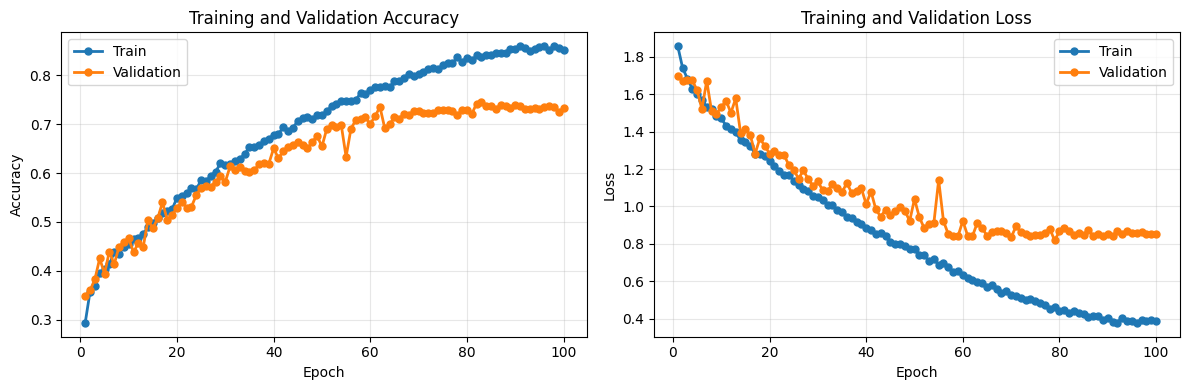

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, NUM_EPOCHS + 1)

# Plot training and validation accuracy
axes[0].plot(epochs_range, history['train_acc'], label='Train', linewidth=2, marker='o', markersize=5)
axes[0].plot(epochs_range, history['val_acc'], label='Validation', linewidth=2, marker='o', markersize=5)
axes[0].set_title('Training and Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot training and validation loss
axes[1].plot(epochs_range, history['train_loss'], label='Train', linewidth=2, marker='o', markersize=5)
axes[1].plot(epochs_range, history['val_loss'], label='Validation', linewidth=2, marker='o', markersize=5)
axes[1].set_title('Training and Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Evaluate the Best Model on the Test Set

In [ ]:
# Load the best model checkpoint saved during validation
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f'Loaded best model from epoch {checkpoint["epoch"]} (val acc {checkpoint["val_acc"]:.4f})')

# Evaluate the best model on the test set
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'\nTest loss: {test_loss:.4f}')
print(f'Test accuracy (class-level): {test_acc:.4f}')

Loaded best model from epoch 83 (val acc 0.7449)

Test loss: 0.8962
Test accuracy (class-level): 0.7314


## 10. Analyze Accuracy Per Class

In [ ]:
def collect_predictions(model, loader, device):
    # Set the model to evaluation mode
    model.eval()
    all_preds, all_labels = [], []

    # Collect predicted labels and true labels from the test set
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

# Collect predicted labels and true labels from the test set
y_pred, y_true = collect_predictions(model, test_loader, device)
print('Accuracy per class')

# Calculate accuracy for each class separately
for i, cls in enumerate(CLASS_NAMES):
    mask = y_true == i
    if mask.sum() > 0:
        acc = (y_pred[mask] == i).mean()
        print(f'  {cls:<10s} {acc:.4f}  ({mask.sum()} samples)')

Accuracy per class
  bicycle    0.8533  (150 samples)
  bird       0.7333  (150 samples)
  car        0.8400  (150 samples)
  cat        0.7133  (150 samples)
  dog        0.6600  (150 samples)
  flower     0.7667  (150 samples)
  fruit      0.6000  (150 samples)
  shoe       0.7333  (150 samples)
  vegetable  0.6767  (133 samples)


## 11. Confusion Matrix and Classification Report

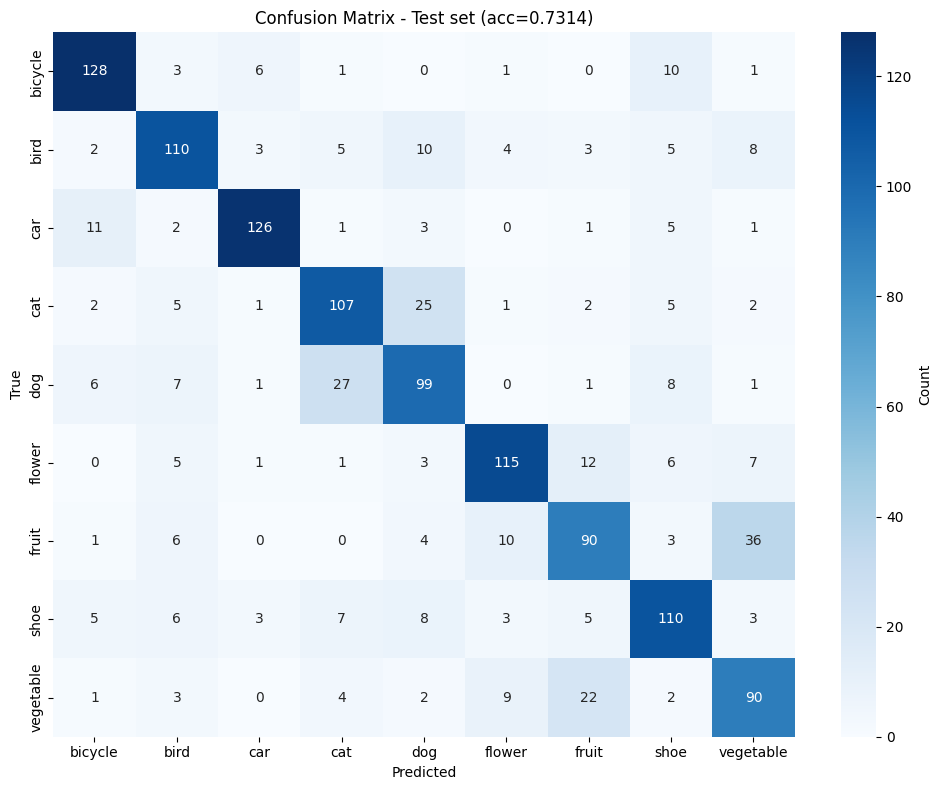


Classification report
              precision    recall  f1-score   support

     bicycle     0.8205    0.8533    0.8366       150
        bird     0.7483    0.7333    0.7407       150
         car     0.8936    0.8400    0.8660       150
         cat     0.6993    0.7133    0.7063       150
         dog     0.6429    0.6600    0.6513       150
      flower     0.8042    0.7667    0.7850       150
       fruit     0.6618    0.6000    0.6294       150
        shoe     0.7143    0.7333    0.7237       150
   vegetable     0.6040    0.6767    0.6383       133

    accuracy                         0.7314      1333
   macro avg     0.7321    0.7307    0.7308      1333
weighted avg     0.7337    0.7314    0.7320      1333



In [ ]:
# Compute the confusion matrix using true and predicted labels
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))

# Visualize how often each true class was predicted as each class
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - Test set (acc={test_acc:.4f})')
plt.tight_layout()
plt.show()

# Print precision, recall, and F1-score for each class
print('\nClassification report')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

In [ ]:
from google.colab import files
files.download(MODEL_SAVE_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>